<a href="https://colab.research.google.com/github/databyhuseyn/sideProjects/blob/main/LinearAlgebraFull.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎯 Machine Learning Motivation

In ML, we constantly solve problems like:

Linear regression

Least squares

Feature interactions

Weight updates

All of these reduce to solving systems of linear equations.

If you don’t understand when a system has
one solution, many solutions, or no solution,
you don’t fully understand ML models.

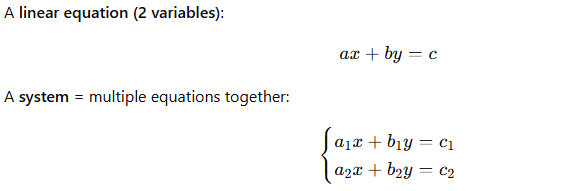

In [ ]:
# Equation 1: 2x + y = 5
# Equation 2: x - y = 1

# Solve manually using numpy
import numpy as np

A = np.array([
    [2, 1],
    [1, -1]
])

b = np.array([5, 1])

solution = np.linalg.solve(A, b)
solution


array([2., 1.])

Systems of Equations as Lines

Each equation in 2D represents a line.

One equation → one line

Two equations → two lines

Solution = intersection point

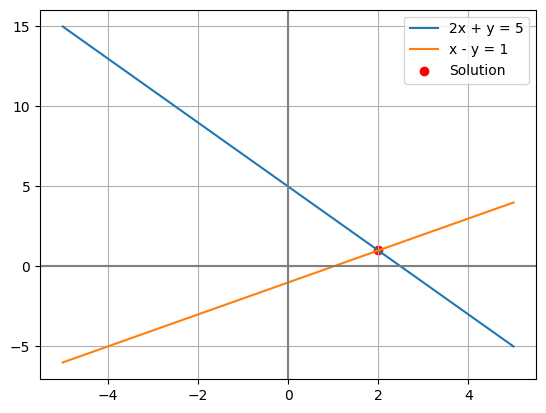

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

y1 = 5 - 2*x      # 2x + y = 5
y2 = x - 1        # x - y = 1 → y = x - 1

plt.plot(x, y1, label="2x + y = 5")
plt.plot(x, y2, label="x - y = 1")
plt.scatter(solution[0], solution[1], color="red", label="Solution")

plt.axhline(0, color='gray')
plt.axvline(0, color='gray')
plt.legend()
plt.grid()
plt.show()


The system has exactly one solution → one intersection.

Three Possible Cases

1️⃣ One solution

Lines intersect at one point

2️⃣ No solution

Lines are parallel

3️⃣ Infinitely many solutions

Lines are the same line

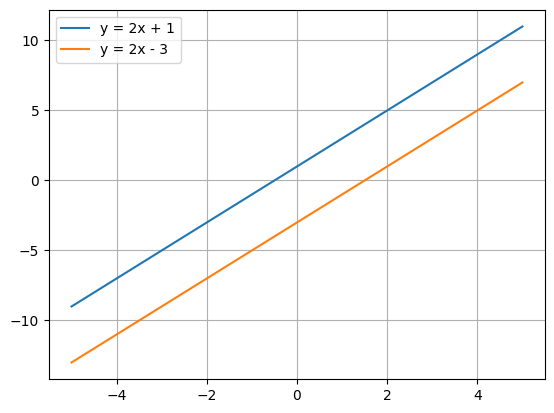

In [ ]:
y1 = 2*x + 1
y2 = 2*x - 3

plt.plot(x, y1, label="y = 2x + 1")
plt.plot(x, y2, label="y = 2x - 3")
plt.legend()
plt.grid()
plt.show()


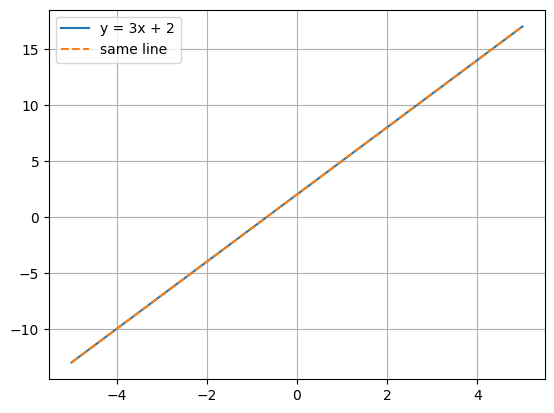

In [ ]:
y1 = 3*x + 2
y2 = 3*x + 2

plt.plot(x, y1, label="y = 3x + 2")
plt.plot(x, y2, '--', label="same line")
plt.legend()
plt.grid()
plt.show()


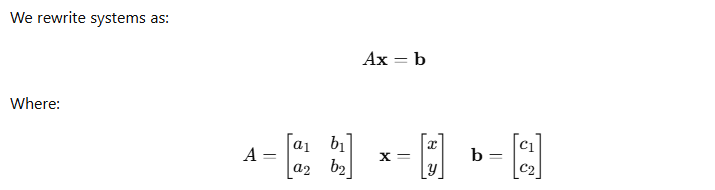

1) Non-singular matrix

One unique solution

Matrix is invertible

2) Singular matrix

No solution OR infinite solutions

Matrix is not invertible

A matrix is invertible (or non-singular) if and only if it's a square matrix (same rows/columns) and its determinant is not zero, meaning there exists another matrix (its inverse) that when multiplied by the original, yields the identity matrix ( \(A\cdot A^{-1}=I\) ).

Invertible matrices have linearly independent rows/columns, full rank, and allow for unique solutions to linear equations (\(Ax=b\)). Key Conditions for Invertibility: Must be Square: A matrix with \(m\) rows and \(n\) columns (\(m\times n\)) must have \(m=n\) to be invertible.Determinant is Non-Zero: The determinant (a scalar value) must not equal zero.Full Rank: The matrix must have full rank (equal to its dimension).Linearly Independent Rows/Columns: No row or column can be a combination of the others.Unique Solution for \(Ax=b\): The equation \(Ax=b\) has a single, unique solution. How to Check (Examples): For a 2x2 Matrix \(\left(\begin{matrix}a&b\\ c&d\end{matrix}\right)\): Calculate the determinant \(ad-bc\). If \(ad-bc\ne 0\), it's invertible.For Larger Matrices: Use methods like Gaussian elimination (row reduction) to find the inverse; if you can reduce it to the identity matrix on one side, it's invertible. Why it Matters: Invertible matrices are crucial for solving systems of linear equations, understanding linear transformations, and in fields like wireless communication (MIMO) where you need to decode signals.

Geometric Notion of Singularity

Rows of A are linearly independent → non-singular

Rows of A are linearly dependent → singular

In 2D:

Independent → lines intersect

Dependent → parallel or same line

In [ ]:
A_singular = np.array([
    [2, 4],
    [1, 2]
])

np.linalg.det(A_singular)


np.float64(0.0)

Determinant = 0 → singular

# Linear Dependence & Independence

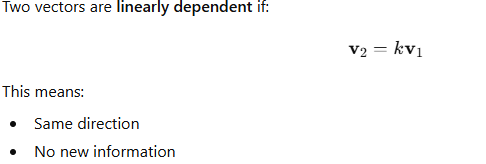

In [ ]:
v1 = np.array([2, 4])
v2 = np.array([1, 2])

print("Are they multiples?", np.allclose(v1, 2*v2))


Are they multiples? True


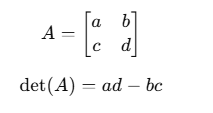

| Determinant | Meaning             |
| ----------- | ------------------- |
| ≠ 0         | Unique solution     |
| = 0         | Singular system     |
|             | Area scaling factor |


In [ ]:
A = np.array([
    [2, 1],
    [1, 1]
])

np.linalg.det(A)


np.float64(1.0)

🧠 Determinant = area scaling factor of the transformation.

In simple terms, a determinant is a special number for square matrices that tells you how much a transformation (like stretching, rotating) changes an area or volume, acting as a scaling factor; a determinant of 2 means area/volume doubles, 0 means it collapses to nothing (a flat line or point), and its sign shows if orientation flips. It's a way to understand the "essence" or "size" of what a matrix does to space.

AI Takeaway 🧠
In Machine Learning:

Singular matrices → unstable models

Rank deficiency → feature collapse

Determinant ≈ information volume

Inversion problems → numerical instability

Good models require well-conditioned systems.

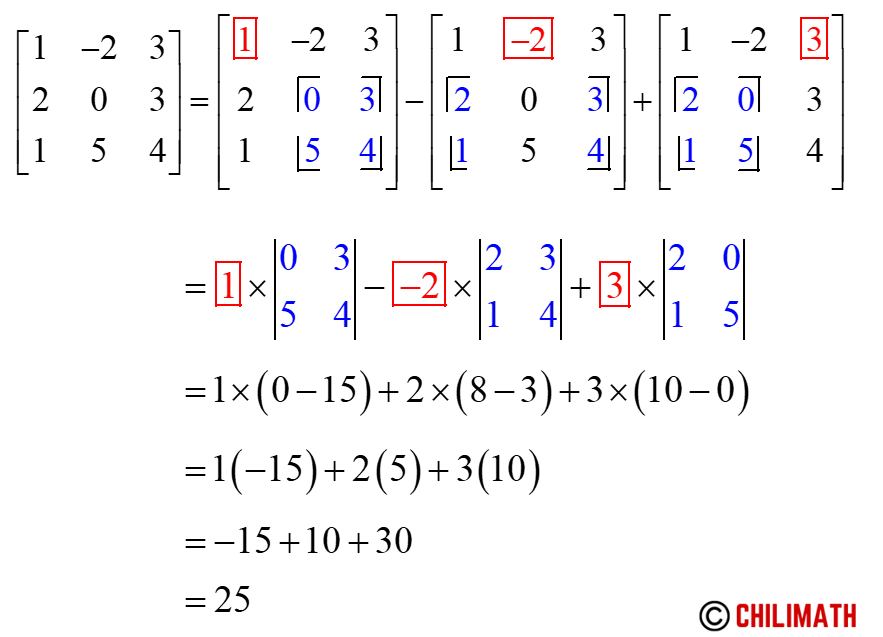

# Lesson 2

🎯 Machine Learning Motivation

Many ML problems involve 3 or more features

3×3 systems represent planes in 3D space

Understanding intersections = understanding feature interactions

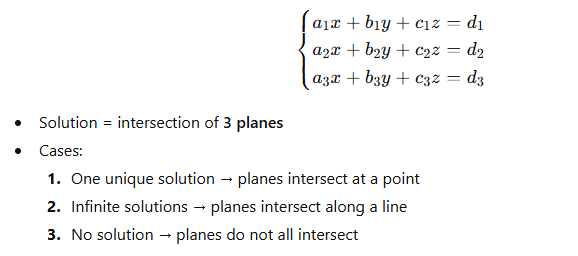

In [1]:
import numpy as np

A = np.array([
    [1, 2, -1],
    [2, -1, 1],
    [3, 1, 1]
])

b = np.array([3, 3, 4])

# Solve
solution = np.linalg.solve(A, b)
solution


array([ 2.2, -0.6, -2. ])

Equation → plane in 3D:
𝑎
𝑥
+
𝑏
𝑦
+
𝑐
𝑧
=
𝑑
ax+by+cz=d

Intersection = solution

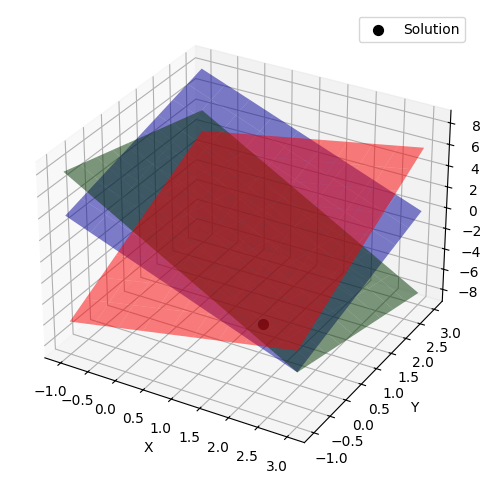

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = np.linspace(-1, 3, 10)
y = np.linspace(-1, 3, 10)
X, Y = np.meshgrid(x, y)

# Plane 1
Z1 = (3 - 1*X - 2*Y)/(-1)
ax.plot_surface(X, Y, Z1, alpha=0.5, color='red')

# Plane 2
Z2 = (3 - 2*X + 1*Y)/(1)
ax.plot_surface(X, Y, Z2, alpha=0.5, color='blue')

# Plane 3
Z3 = (4 - 3*X - 1*Y)/(1)
ax.plot_surface(X, Y, Z3, alpha=0.5, color='green')

# Solution point
ax.scatter(solution[0], solution[1], solution[2], color='black', s=50, label='Solution')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()


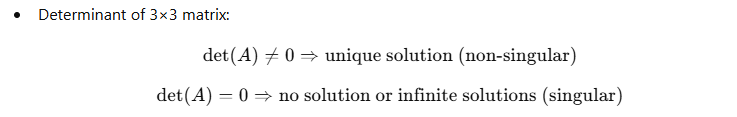

In [3]:
det = np.linalg.det(A)
det


np.float64(-4.999999999999998)

If det ≠ 0 → unique intersection (point)

If det = 0 → singular (planes coincide or never intersect)

Vectors representing plane normals

Linearly dependent → singular matrix

Linearly independent → non-singular

In [4]:
v1 = np.array([1, 2, -1])
v2 = np.array([2, -1, 1])
v3 = np.array([3, 1, 1])

# Check rank
rank = np.linalg.matrix_rank(np.vstack([v1, v2, v3]))
rank


np.int64(3)

Rank = 3 → independent → unique solution

Rank < 3 → dependent → singular

| Case     | Rank | Determinant | Geometric                 |
| -------- | ---- | ----------- | ------------------------- |
| Unique   | 3    | ≠ 0         | Intersection at a point   |
| Infinite | < 3  | 0           | Intersection along a line |
| None     | < 3  | 0           | No intersection           |


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_planes(eqs, sol=None, title=""):
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')

    x = np.linspace(-3,3,20)
    y = np.linspace(-3,3,20)
    X, Y = np.meshgrid(x,y)

    colors = ['red','blue','green']

    for (a,b,c,d), color in zip(eqs, colors):
        if c != 0:
            Z = (d - a*X - b*Y)/c
            ax.plot_surface(X,Y,Z, alpha=0.4, color=color)

    if sol is not None:
        ax.scatter(sol[0], sol[1], sol[2], color='black', s=60)

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()


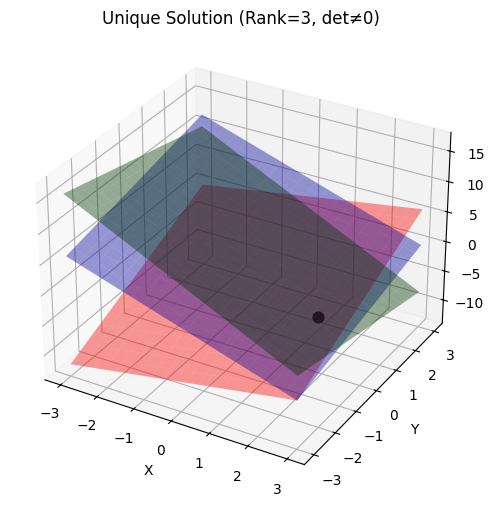

In [7]:
A = np.array([
    [1, 2, -1],
    [2, -1, 1],
    [3, 1, 1]
])
b = np.array([3, 3, 4])

sol = np.linalg.solve(A,b)

eqs = [
    (1, 2, -1, 3),
    (2, -1, 1, 3),
    (3, 1, 1, 4)
]

plot_planes(eqs, sol, "Unique Solution (Rank=3, det≠0)")


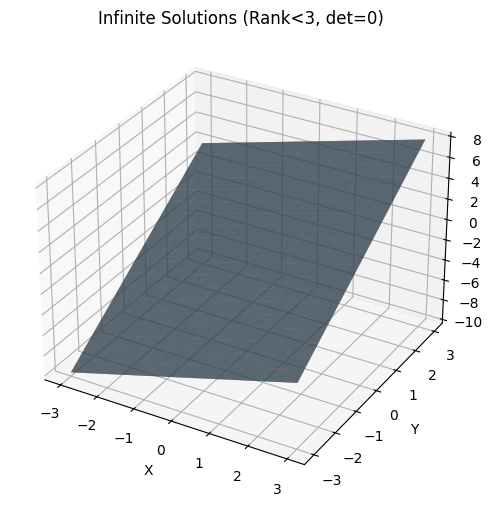

In [8]:
eqs = [
    (1, 2, -1, 1),
    (2, 4, -2, 2),
    (3, 6, -3, 3)
]

plot_planes(eqs, title="Infinite Solutions (Rank<3, det=0)")


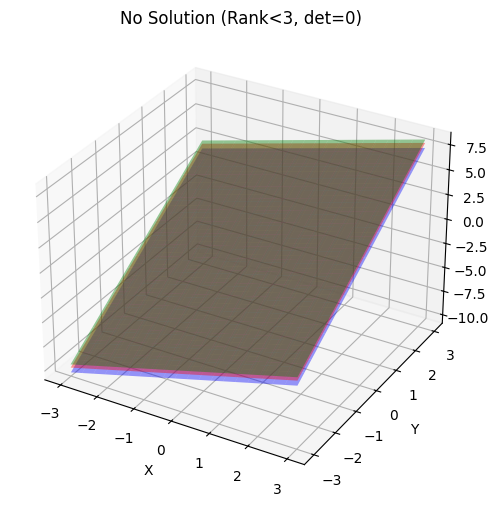

In [9]:
eqs = [
    (1, 2, -1, 1),
    (2, 4, -2, 3),
    (3, 6, -3, 2)
]

plot_planes(eqs, title="No Solution (Rank<3, det=0)")


| Situation       | ML Interpretation     |
| --------------- | --------------------- |
| Rank = features | Healthy model         |
| Rank < features | Redundant features    |
| det ≈ 0         | Numerical instability |
| det = 0         | Impossible inversion  |


In [10]:
A_singular = np.array([
    [1, 2, -1],
    [2, 4, -2],
    [3, 6, -3]
])

b_singular = np.array([1, 2, 3])

print("Determinant:", np.linalg.det(A_singular))
print("Rank:", np.linalg.matrix_rank(A_singular))


Determinant: 0.0
Rank: 1


det = 0 → singular

rank < 3 → infinite solutions (planes coincide)

Non-singular 3×3 → stable ML solution

Singular → degenerate features or over-parameterization

Determinant ≈ volume scaling

Rank = number of independent features

Understanding planes in 3D is the geometric foundation for higher-dimensional ML problems.

# Lesson 3

🎯 Machine Learning Motivation

Linear regression = solving
𝐴
𝑥
=
𝑏
Ax=b

Feature selection = checking for rank deficiency

Numerical stability = understanding singular systems

Goal: Solve systems manually and programmatically, even when singular or with many variables.

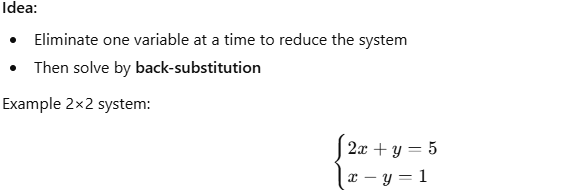

In [12]:
# 2x + y = 5 → y = 5 - 2x
# x - y = 1

# Substitute y into second equation
# x - (5 - 2x) = 1 → 3x - 5 = 1 → x = 2
x = 2
y = 5 - 2*x
x, y


(2, 1)

Gaussian Elimination

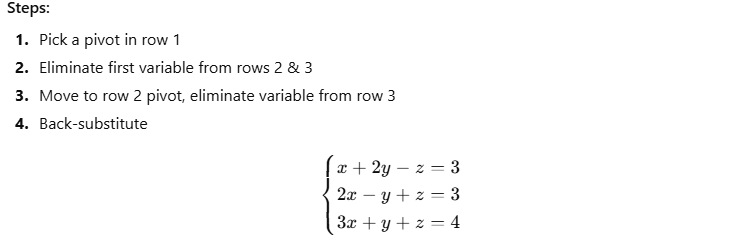

In [13]:
A = np.array([
    [1, 2, -1],
    [2, -1, 1],
    [3, 1, 1]
], dtype=float)

b = np.array([3, 3, 4], dtype=float)

# Step 1: Eliminate x from rows 2 and 3
A[1] = A[1] - 2*A[0]
b[1] = b[1] - 2*b[0]

A[2] = A[2] - 3*A[0]
b[2] = b[2] - 3*b[0]

# Step 2: Eliminate y from row 3
factor = A[2,1] / A[1,1]
A[2] = A[2] - factor*A[1]
b[2] = b[2] - factor*b[1]

# Step 3: Back-substitution
z = b[2] / A[2,2]
y = (b[1] - A[1,2]*z) / A[1,1]
x = (b[0] - A[0,1]*y - A[0,2]*z) / A[0,0]

x, y, z


(np.float64(2.2), np.float64(-0.6), np.float64(-2.0))

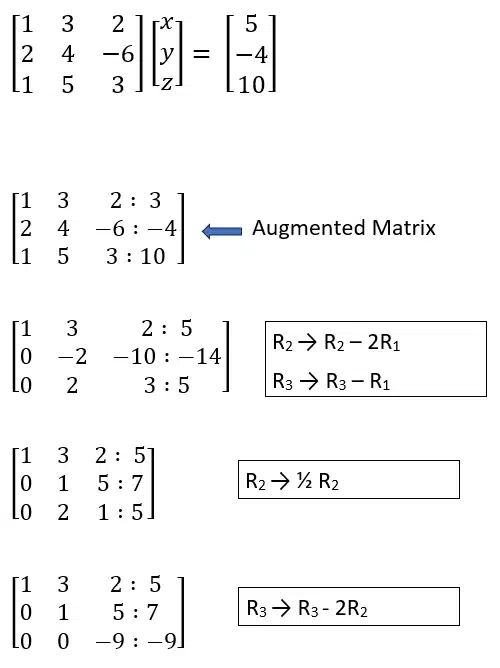

Row Operations That Preserve Solutions

Swap rows → solution unchanged

Multiply row by non-zero scalar → solution unchanged

Add multiple of one row to another → solution unchanged

In [14]:
# Original
A = np.array([
    [2, 1],
    [4, 3]
], dtype=float)
b = np.array([5, 11], dtype=float)

# Operation: R2 → R2 - 2*R1
A[1] = A[1] - 2*A[0]
b[1] = b[1] - 2*b[0]

A, b


(array([[2., 1.],
        [0., 1.]]),
 array([5., 1.]))

Gaussian Elimination in Python (np.linalg.solve)

In [15]:
# Non-singular 3x3 system
A = np.array([
    [1, 2, -1],
    [2, -1, 1],
    [3, 1, 1]
], dtype=float)
b = np.array([3, 3, 4], dtype=float)

solution = np.linalg.solve(A, b)
solution


array([ 2.2, -0.6, -2. ])

✅ Much faster for larger systems

det(A) = 0 → singular

Can still do elimination → leads to row of zeros

Infinite solutions → parametrize free variable

In [16]:
A_singular = np.array([
    [1, 2, -1],
    [2, 4, -2],
    [3, 6, -3]
], dtype=float)
b_singular = np.array([3, 6, 9], dtype=float)

# Check determinant
np.linalg.det(A_singular)


np.float64(0.0)

In [17]:
# Check rank
np.linalg.matrix_rank(A_singular)


np.int64(1)

AI Takeaway 🧠

Gaussian elimination = manual linear regression

Singular matrices → features are dependent → overfitting risk

Rank check → how many independent features

Row operations → core to backprop in linear layers